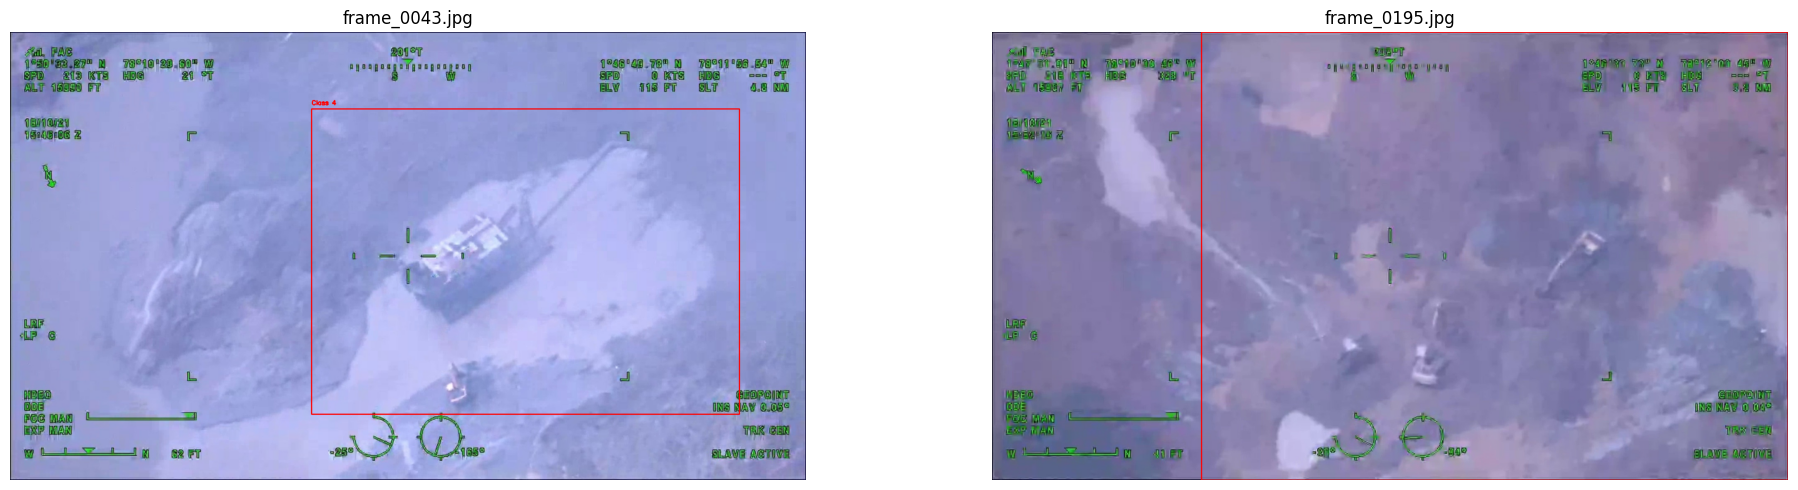

In [1]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

def display_random_images_with_bboxes(frames_dir, labels_dir, num_images=2):
    # Get list of image files
    image_files = [f for f in os.listdir(frames_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    # Select random images
    selected_images = random.sample(image_files, min(num_images, len(image_files)))
    
    # Set up plot
    fig, axes = plt.subplots(1, num_images, figsize=(10 * num_images, 5))
    if num_images == 1:
        axes = [axes]
    
    for idx, image_file in enumerate(selected_images):
        # Load image
        image_path = os.path.join(frames_dir, image_file)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display
        height, width = image.shape[:2]
        
        # Load corresponding label file
        label_file = os.path.splitext(image_file)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_file)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            # Draw bounding boxes
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, center_x, center_y, bbox_width, bbox_height = map(float, parts)
                    
                    # Convert normalized coordinates to pixel values
                    x_min = int((center_x - bbox_width / 2) * width)
                    y_min = int((center_y - bbox_height / 2) * height)
                    x_max = int((center_x + bbox_width / 2) * width)
                    y_max = int((center_y + bbox_height / 2) * height)
                    
                    # Draw rectangle on image
                    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
                    # Optionally, add class label
                    cv2.putText(image, f'Class {int(class_id)}', (x_min, y_min - 10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        
        # Display image
        axes[idx].imshow(image)
        axes[idx].set_title(image_file)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    frames_dir = "mineria2/frames"
    labels_dir = "mineria2/labels"
    display_random_images_with_bboxes(frames_dir, labels_dir, num_images=2)